# 04 — Consumption Forecast
Predict 15-min household consumption (`verbruik_kwh`) using time features,
lag features, and weather data from Open-Meteo.

Goal: test whether a better forecast reduces the 85 EUR/yr LP gap found in §10.

## 0. Imports and file paths

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import json
import holidays
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── File paths ────────────────────────────────────────────────────────────────
DATA_FILE    = "../../Data/real_load/Final/optimization_input.csv"
WEATHER_FILE = "../../Data/real_load/Final/weather_personal.csv"
OUTPUT_FILE  = "../../Data/real_load/Final/consumption_forecast.csv"

print("Imports OK")

Imports OK


## 1. Load consumption data

In [27]:
# Load the 15-min consumption + price data
df = pd.read_csv(DATA_FILE, parse_dates=["kwartier"], index_col="kwartier")
df = df.sort_index()

print(f"Rows:   {len(df):,}")
print(f"Period: {df.index.min().date()} → {df.index.max().date()}")
print(f"Average consumption per slot: {df['verbruik_kwh'].mean():.4f} kWh")
print()
print(df["verbruik_kwh"].describe().round(4))

Rows:   50,112
Period: 2024-11-01 → 2026-04-06
Average consumption per slot: 0.1779 kWh

count    50112.0000
mean         0.1779
std          0.1645
min          0.0000
25%          0.0670
50%          0.1450
75%          0.2500
max          1.6040
Name: verbruik_kwh, dtype: float64


## 2. Fetch weather data (Open-Meteo)

We use the free Open-Meteo historical archive API (no key needed).
Location: Antwerp (lat=51.22, lon=4.40).
Variables: temperature, apparent temperature, precipitation, cloud cover.

In [28]:
import os

# Only download if the file doesn't exist yet
if os.path.exists(WEATHER_FILE):
    print("Weather file already exists — loading from disk.")
    weather = pd.read_csv(WEATHER_FILE, parse_dates=["time"], index_col="time")
else:
    # Build the API URL
    start = df.index.min().strftime("%Y-%m-%d")
    end   = df.index.max().strftime("%Y-%m-%d")

    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=51.22&longitude=4.40"
        f"&start_date={start}&end_date={end}"
        "&hourly=temperature_2m,apparent_temperature,precipitation,cloudcover"
        "&timezone=Europe%2FBrussels"
    )

    print("Fetching weather from Open-Meteo...")
    with urllib.request.urlopen(url, timeout=30) as resp:
        raw = json.loads(resp.read())

    # Convert to DataFrame
    weather = pd.DataFrame(raw["hourly"])
    weather["time"] = pd.to_datetime(weather["time"])
    weather = weather.set_index("time")

    # Save so we don't fetch again next run
    weather.to_csv(WEATHER_FILE)
    print(f"Saved to {WEATHER_FILE}")

print(f"Weather rows: {len(weather):,}")
print(f"Columns: {weather.columns.tolist()}")
print(weather.head(3))

Weather file already exists — loading from disk.
Weather rows: 12,528
Columns: ['temperature_2m', 'apparent_temperature', 'precipitation', 'cloudcover']
                     temperature_2m  apparent_temperature  precipitation  \
time                                                                       
2024-11-01 00:00:00             7.7                   5.5            0.0   
2024-11-01 01:00:00             8.6                   6.9            0.0   
2024-11-01 02:00:00             8.6                   7.0            0.0   

                     cloudcover  
time                             
2024-11-01 00:00:00           0  
2024-11-01 01:00:00           0  
2024-11-01 02:00:00           5  


## 3. Merge weather into main dataframe

Weather is hourly; our data is 15-min.
We resample to 15-min by forward-filling each hourly value into 4 slots.

In [29]:
# Resample hourly weather to 15-min by repeating each value 4 times
weather_15min = weather.resample("15min").ffill()

# Add weather columns to our main dataframe
df = df.join(weather_15min, how="left")

# Fill any remaining NaN at the edges (e.g. last few slots after final weather timestamp)
df[["temperature_2m", "apparent_temperature", "precipitation", "cloudcover"]] = (
    df[["temperature_2m", "apparent_temperature", "precipitation", "cloudcover"]]
    .ffill()
    .bfill()
)

# Confirm no missing values remain
missing = df[["temperature_2m", "apparent_temperature", "precipitation", "cloudcover"]].isna().sum()
print("Missing weather values per column:")
print(missing)

Missing weather values per column:
temperature_2m          0
apparent_temperature    0
precipitation           0
cloudcover              0
dtype: int64


## 4. Feature engineering

Three groups of features:
- **Time features**: slot, weekday, month, is_weekend — tell the model about daily/weekly patterns
- **Lag features**: consumption yesterday and last week at the same time — give the model "memory"
- **Weather features**: temperature, cloudcover, etc.

In [30]:
# ── Time features ─────────────────────────────────────────────────────────────
df["slot"]       = df.index.hour * 4 + df.index.minute // 15  # 0..95
df["hour"]       = df.index.hour
df["weekday"]    = df.index.weekday      # 0 = Monday, 6 = Sunday
df["month"]      = df.index.month
df["is_weekend"] = (df.index.weekday >= 5).astype(int)

# Belgian public holidays (e.g. Christmas, Easter, Labour Day, ...)
# People at home → consumption pattern similar to Sunday
be_holidays = holidays.Belgium()
df["is_holiday"] = df.index.normalize().isin(be_holidays).astype(int)

print(f"Holiday days in dataset: {df['is_holiday'].resample('D').max().sum()}")

# ── Lag features ──────────────────────────────────────────────────────────────
# Same slot 24 hours ago (96 slots back)
df["lag_96"]  = df["verbruik_kwh"].shift(96)
# Same slot 7 days ago (672 slots back)
df["lag_672"] = df["verbruik_kwh"].shift(672)
# Average consumption over the last 24 hours (shift by 1 to avoid leakage)
df["roll_mean_96"] = df["verbruik_kwh"].shift(1).rolling(96).mean()

print("Feature columns added.")
print(f"Rows with NaN lags (first 7 days): {df['lag_672'].isna().sum():,}")
print()
print(df[["verbruik_kwh", "lag_96", "lag_672", "roll_mean_96", "temperature_2m"]].head(8))

Holiday days in dataset: 0
Feature columns added.
Rows with NaN lags (first 7 days): 672

                     verbruik_kwh  lag_96  lag_672  roll_mean_96  \
kwartier                                                           
2024-11-01 00:00:00         0.000     NaN      NaN           NaN   
2024-11-01 00:15:00         0.392     NaN      NaN           NaN   
2024-11-01 00:30:00         0.324     NaN      NaN           NaN   
2024-11-01 00:45:00         0.113     NaN      NaN           NaN   
2024-11-01 01:00:00         0.140     NaN      NaN           NaN   
2024-11-01 01:15:00         0.135     NaN      NaN           NaN   
2024-11-01 01:30:00         0.109     NaN      NaN           NaN   
2024-11-01 01:45:00         0.093     NaN      NaN           NaN   

                     temperature_2m  
kwartier                             
2024-11-01 00:00:00             7.7  
2024-11-01 00:15:00             7.7  
2024-11-01 00:30:00             7.7  
2024-11-01 00:45:00             7.7  
2

## 5. Train / test split

We use a **chronological split**: train on older data, test on newer data.
This simulates real deployment — the model only sees the past.

- Train: Nov 2024 – Dec 2025 (~13 months)
- Test: Jan 2026 – Apr 2026 (~4 months)

In [31]:
# Drop rows with NaN (first 7 days, because of lag_672)
df_model = df.dropna(subset=["lag_96", "lag_672", "roll_mean_96", "temperature_2m"])

# List of features the model will use
FEATURES = [
    "slot", "weekday", "month", "is_weekend", "is_holiday",  # time
    "lag_96", "lag_672", "roll_mean_96",                       # lags
    "temperature_2m", "apparent_temperature",                  # weather
    "precipitation", "cloudcover",
]

X = df_model[FEATURES]
y = df_model["verbruik_kwh"]

# Split at 2026-01-01
SPLIT = "2026-01-01"

X_train = X[X.index <  SPLIT]
X_test  = X[X.index >= SPLIT]
y_train = y[y.index <  SPLIT]
y_test  = y[y.index >= SPLIT]

print(f"Train: {len(X_train):,} rows  "
      f"({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test:  {len(X_test):,}  rows  "
      f"({X_test.index.min().date()} → {X_test.index.max().date()})")

Train: 40,224 rows  (2024-11-08 → 2025-12-31)
Test:  9,216  rows  (2026-01-01 → 2026-04-06)


## 6. Train model

We use `HistGradientBoostingRegressor` from scikit-learn:
- 200 small decision trees, each fixing the mistakes of the previous one
- `max_leaf_nodes=31`: each tree stays simple (avoids overfitting)
- `learning_rate=0.05`: small steps → more stable learning

In [32]:
# Create the model
model = HistGradientBoostingRegressor(
    max_iter=200,         # number of trees
    max_leaf_nodes=31,    # tree complexity
    learning_rate=0.05,   # step size
    random_state=42       # reproducibility
)

print("Training...")
model.fit(X_train, y_train)
print("Done!")

# Predict on test set
y_pred = pd.Series(
    np.clip(model.predict(X_test), 0, None),  # clip negatives (consumption >= 0)
    index=X_test.index,
    name="verbruik_fc"
)

Training...
Done!


In [39]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

joblib.dump(model, models_dir / "consumption_model.pkl")
print(f"Model saved: {models_dir / 'consumption_model.pkl'}")
print(f"Features used: {FEATURES}")

Model saved: ..\models\consumption_model.pkl
Features used: ['slot', 'weekday', 'month', 'is_weekend', 'is_holiday', 'lag_96', 'lag_672', 'roll_mean_96', 'temperature_2m', 'apparent_temperature', 'precipitation', 'cloudcover']


## 7. Evaluate — ML model vs average profile

We compare two forecasts on the **test period** (Jan–Apr 2026):
- **Average profile**: mean per (weekday, slot) — what §10a used (rough baseline)
- **ML model**: HistGradientBoosting with lag + weather features

In [33]:
# ── Average profile baseline ──────────────────────────────────────────────────
# Build profile from TRAIN data only (no leakage)
profile_train = (
    df_model[df_model.index < SPLIT]
    .groupby(["weekday", "slot"])["verbruik_kwh"]
    .mean()
    .to_dict()
)

# Apply profile to test set
y_profile = X_test.apply(
    lambda r: profile_train.get((int(r["weekday"]), int(r["slot"])), float(y_train.mean())),
    axis=1
)

# ── Compute metrics ────────────────────────────────────────────────────────────
mae_ml       = mean_absolute_error(y_test, y_pred)
mae_profile  = mean_absolute_error(y_test, y_profile)
rmse_ml      = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_profile = np.sqrt(mean_squared_error(y_test, y_profile))

print(f"{'Forecast':35s}  {'MAE (kWh)':>10}  {'RMSE (kWh)':>10}")
print("-" * 60)
print(f"{'Average profile (§10a)':35s}  {mae_profile:10.4f}  {rmse_profile:10.4f}")
print(f"{'ML model':35s}  {mae_ml:10.4f}  {rmse_ml:10.4f}")
print()
print(f"MAE  improvement:  {(1 - mae_ml  / mae_profile) * 100:+.1f}%")
print(f"RMSE improvement:  {(1 - rmse_ml / rmse_profile) * 100:+.1f}%")

Forecast                              MAE (kWh)  RMSE (kWh)
------------------------------------------------------------
Average profile (§10a)                   0.1088      0.1655
ML model                                 0.1034      0.1530

MAE  improvement:  +5.0%
RMSE improvement:  +7.5%


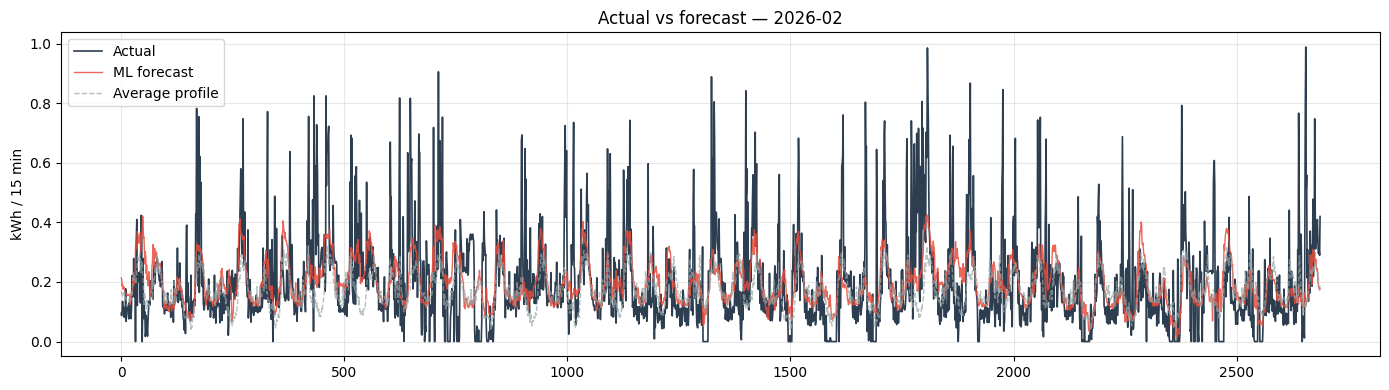

In [34]:
# ── Visual check: one week of predictions ─────────────────────────────────────
week = "2026-02"   # pick a month to zoom in

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test[week].values,    label="Actual",          color="#2c3e50", lw=1.2)
ax.plot(y_pred[week].values,    label="ML forecast",     color="#e74c3c", lw=1,   alpha=0.85)
ax.plot(y_profile[week].values, label="Average profile", color="#95a5a6", lw=1,   alpha=0.7,
        linestyle="--")
ax.set_ylabel("kWh / 15 min")
ax.set_title(f"Actual vs forecast — {week}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Computing permutation importance (may take ~30s)...


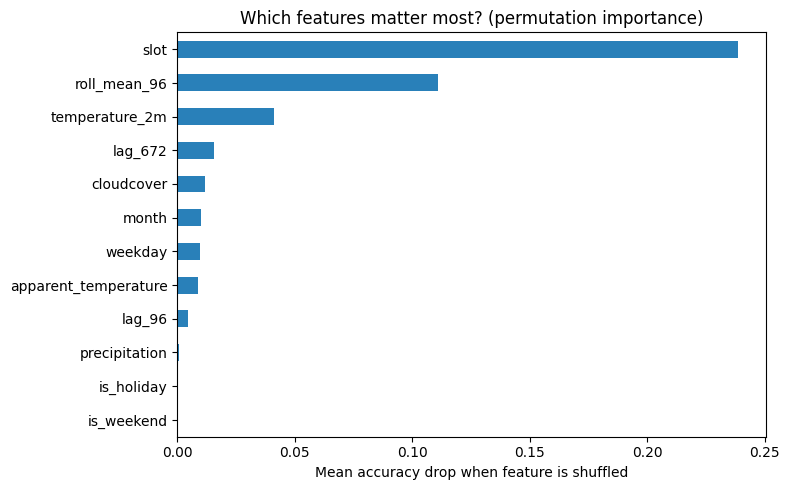

In [35]:
# ── Feature importance via permutation ────────────────────────────────────────
# Permutation importance: shuffle one feature at a time → measure accuracy drop
# Big drop = feature is important; small drop = model doesn't need it much
from sklearn.inspection import permutation_importance

print("Computing permutation importance (may take ~30s)...")
result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,       # shuffle each feature 10 times and average
    random_state=42
)

importances = pd.Series(
    result.importances_mean,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="#2980b9")
ax.set_title("Which features matter most? (permutation importance)")
ax.set_xlabel("Mean accuracy drop when feature is shuffled")
plt.tight_layout()
plt.show()

## 8. Export predictions

Generate predictions for the **full dataset** using the trained model.
These will be used in §10d of `03_optimization_solar.ipynb` to run the LP backtest
with ML consumption forecast instead of the average profile.

In [37]:
# Predict on all rows (not just test) with the model trained on train data
y_all = pd.Series(
    np.clip(model.predict(X), 0, None),
    index=X.index,
    name="verbruik_fc"
)

# Save to CSV
y_all.to_csv(OUTPUT_FILE)

print(f"Saved {len(y_all):,} predictions → {OUTPUT_FILE}")
print()
print(y_all.describe().round(4))

Saved 49,440 predictions → ../../Data/real_load/Final/consumption_forecast.csv

count    49440.0000
mean         0.1765
std          0.0840
min          0.0000
25%          0.1246
50%          0.1671
75%          0.2294
max          1.0369
Name: verbruik_fc, dtype: float64
